In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
from sklearn.model_selection import train_test_split
from model import EEGSpectrogramCNNLSTM
from config import WINDOWS_DIR
from model import EEGSpectrogramCNN
from evaluate import evaluate_model

ImportError: cannot import name 'EEGSpectrogramCNNLSTM' from 'model' (d:\project\src\model.py)

In [2]:
class EEGDataset(Dataset):
    def __init__(self, npz_files):
        self.X = []
        self.y = []
        for f in npz_files:
            data = np.load(f)
            self.X.append(data['X'])
            self.y.append(data['y'])
            
        self.X = np.concatenate(self.X, axis=0)
        self.y = np.concatenate(self.y, axis=0)
        
        mean = np.mean(self.X, axis=(-2, -1), keepdims=True)
        std = np.std(self.X, axis=(-2, -1), keepdims=True) + 1e-8
        self.X = (self.X - mean) / std

    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [5]:
def train_lopo(max_epochs=20, batch_size=64, initial_lr=0.0003, patience=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    
    all_npz_files = list(WINDOWS_DIR.glob("*_spectrograms.npz"))
    all_patients = sorted(list(set([f.name.split('_')[0] for f in all_npz_files])))
    
    os.makedirs("models", exist_ok=True)
    
    for test_patient in all_patients:
        print(f"\n{'='*60}")
        print(f"Fold: Testing on {test_patient} (Training on all others)")
        print(f"{'='*60}")
        
        train_pool_files = [f for f in all_npz_files if test_patient not in f.name]
        test_files = [f for f in all_npz_files if test_patient in f.name]
        
        if not test_files:
            continue
            
        train_files, val_files = train_test_split(train_pool_files, test_size=0.2, random_state=42)
            
        print("Loading training and validation data into memory...")
        train_dataset = EEGDataset(train_files)
        val_dataset = EEGDataset(val_files)
        
        # --- BALANCED BATCH SAMPLER ---
        class_counts = np.bincount(train_dataset.y, minlength=3)
        class_counts = np.where(class_counts == 0, 1, class_counts) # Prevent division by zero
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[train_dataset.y]
        
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Class distribution in train split: {class_counts}")
        print("WeightedRandomSampler active. Every batch will have equal class probability.")
        
        model = EEGSpectrogramCNN(num_classes=3).to(device)
        criterion = FocalLoss(gamma=2.0)
        optimizer = optim.Adam(model.parameters(), lr=initial_lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        model_path = f"models/cnn_fold_{test_patient}.pth"
        
        for epoch in range(max_epochs):
            # --- TRAIN PHASE ---
            model.train()
            running_train_loss = 0.0
            
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                running_train_loss += loss.item()
                
            avg_train_loss = running_train_loss / len(train_loader)
            
            # --- VALIDATION PHASE ---
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    running_val_loss += loss.item()
                    
            avg_val_loss = running_val_loss / len(val_loader)
            
            print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
            scheduler.step(avg_val_loss)
            
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), model_path)
                print(f"  [*] Val loss improved. Saved checkpoint.")
            else:
                epochs_no_improve += 1
                print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
                
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                break
                
        print(f"\nFinished fold training. Best model saved to {model_path}")
        
        # --- EVALUATE ON HELD-OUT PATIENT ---
        print(f"Loading test data for {test_patient}...")
        test_dataset = EEGDataset(test_files)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) 
        
        model.load_state_dict(torch.load(model_path, weights_only=True))
        evaluate_model(model, test_loader, device)
        
        break 

# Start the training!
train_lopo()

Training on device: cuda

Fold: Testing on chb01 (Training on all others)
Loading training and validation data into memory...
Class distribution in train split: [156412   4318    723]
WeightedRandomSampler active. Every batch will have equal class probability.
Epoch [1/20] | Train Loss: 0.1130 | Val Loss: 0.3682
  [*] Val loss improved. Saved checkpoint.
Epoch [2/20] | Train Loss: 0.0706 | Val Loss: 0.4039
  [!] No improvement for 1 epoch(s).
Epoch [3/20] | Train Loss: 0.0583 | Val Loss: 0.2719
  [*] Val loss improved. Saved checkpoint.
Epoch [4/20] | Train Loss: 0.0493 | Val Loss: 0.4479
  [!] No improvement for 1 epoch(s).
Epoch [5/20] | Train Loss: 0.0431 | Val Loss: 0.3305
  [!] No improvement for 2 epoch(s).
Epoch [6/20] | Train Loss: 0.0384 | Val Loss: 0.3510
  [!] No improvement for 3 epoch(s).
Epoch [7/20] | Train Loss: 0.0268 | Val Loss: 0.3615
  [!] No improvement for 4 epoch(s).
Epoch [8/20] | Train Loss: 0.0239 | Val Loss: 0.3603
  [!] No improvement for 5 epoch(s).

Early 

Searching your dataset for exactly one example of all 3 classes...
Successfully found all 3 classes! Generating plot...


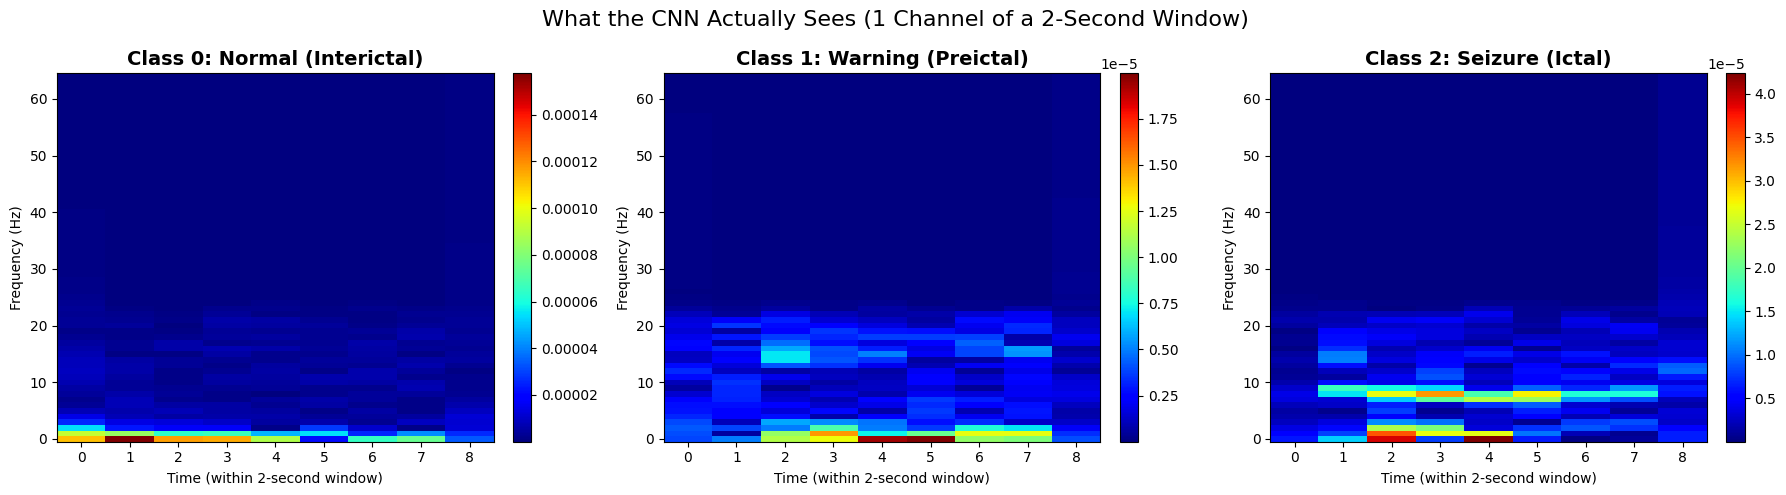

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random
from config import WINDOWS_DIR

def visualize_eeg_classes():
    print("Searching your dataset for exactly one example of all 3 classes...")
    
    # Storage for our examples
    examples = {0: None, 1: None, 2: None}
    class_names = {0: "Normal (Interictal)", 1: "Warning (Preictal)", 2: "Seizure (Ictal)"}
    
    # Grab a list of files and shuffle them so we don't just search Class 0 forever
    all_files = list(WINDOWS_DIR.glob("*_spectrograms.npz"))
    random.shuffle(all_files)
    
    for f in all_files:
        data = np.load(f)
        X, y = data['X'], data['y']
        
        # Look for the classes we still haven't found yet
        for target_class in [0, 1, 2]:
            if examples[target_class] is None:
                # Find indices where this label exists in the array
                indices = np.where(y == target_class)[0]
                if len(indices) > 0:
                    # Grab the very first image of this class that we find
                    examples[target_class] = X[indices[0]]
                    
        # If we successfully found all 3 classes, stop searching!
        if all(v is not None for v in examples.values()):
            print("Successfully found all 3 classes! Generating plot...")
            break
            
    # --- Generate the Visual Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, target_class in enumerate([0, 1, 2]):
        ax = axes[i]
        if examples[target_class] is not None:
            # We select [0] to just show the 1st EEG channel out of the 22 channels
            spectrogram = examples[target_class][0] 
            
            # Draw the spectrogram heat map
            im = ax.imshow(spectrogram, aspect='auto', origin='lower', cmap='jet')
            ax.set_title(f"Class {target_class}: {class_names[target_class]}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Time (within 2-second window)")
            ax.set_ylabel("Frequency (Hz)")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.set_title(f"Class {target_class} Not Found in searched files.")
            
    plt.suptitle("What the CNN Actually Sees (1 Channel of a 2-Second Window)", fontsize=16)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_eeg_classes()

In [7]:
import numpy as np
from config import WINDOWS_DIR

def count_all_labels():
    print("Scanning all dataset files for label counts... This might take a few seconds.\n")
    
    # Dictionary to keep our running totals
    total_counts = {0: 0, 1: 0, 2: 0}
    total_windows = 0
    
    # Grab all the saved spectrogram files
    all_files = list(WINDOWS_DIR.glob("*_spectrograms.npz"))
    
    if not all_files:
        print("No .npz files found! Check your WINDOWS_DIR path.")
        return

    # Loop through every file and add up the labels
    for f in all_files:
        data = np.load(f)
        y = data['y']
        
        # Find unique labels and how many times they appear in this file
        unique_classes, counts = np.unique(y, return_counts=True)
        
        for cls, count in zip(unique_classes, counts):
            total_counts[cls] += count
            total_windows += count
            
    # Print the final report
    print("=" * 50)
    print("--- TOTAL DATASET LABEL COUNTS ---")
    print(f"Class 0 (Normal / Interictal) : {total_counts.get(0, 0):,}")
    print(f"Class 1 (Warning / Preictal)  : {total_counts.get(1, 0):,}")
    print(f"Class 2 (Seizure / Ictal)     : {total_counts.get(2, 0):,}")
    print("-" * 50)
    print(f"Total 2-Second Windows        : {total_windows:,}")
    print("=" * 50)

if __name__ == "__main__":
    count_all_labels()

Scanning all dataset files for label counts... This might take a few seconds.

--- TOTAL DATASET LABEL COUNTS ---
Class 0 (Normal / Interictal) : 253,972
Class 1 (Warning / Preictal)  : 8,677
Class 2 (Seizure / Ictal)     : 1,025
--------------------------------------------------
Total 2-Second Windows        : 263,674
